# Khai phá đồ thị IUH - 2025

### Lab 01. Đáp án.

### 1) Cài đặt graph cơ bản.

In [3]:
#Cho graph vô hướng sau đây với thông tin danh sách cạnh kề
graph = {
  '1' : ['3', '5'],
  '2' : ['3'],
  '3' : ['1', '2', '4', '5'],
  '4' : ['3', '7'],
  '5' : ['1', '3', '6'],
  '6' : ['5', '7'],
  '7' : ['4', '6']
}

Hãy viết code thực hiện các yêu cầu sau đây:
1) Tính số đỉnh của graph, cho biết bậc của đỉnh '1'.

In [17]:
#dưới đây là 2 cách giải (dùng/không dùng networkx)
len(graph), len(graph['1'])

(7, 2)

In [5]:
import networkx as nx
G = nx.Graph(graph)
G.order(), G.degree('1')

(7, 2)

2) Hãy in ra ma trận đỉnh kề của graph trên.

In [11]:
matrix = []
for u in range(1, num+1):
    s = []
    for v in range(1, num+1):
        if str(v) in graph[str(u)]:
            s.append(1)
        else:
            s.append(0)
    matrix.append(s)
matrix

[[0, 0, 1, 0, 1, 0, 0],
 [0, 0, 1, 0, 0, 0, 0],
 [1, 1, 0, 1, 1, 0, 0],
 [0, 0, 1, 0, 0, 0, 1],
 [1, 0, 1, 0, 0, 1, 0],
 [0, 0, 0, 0, 1, 0, 1],
 [0, 0, 0, 1, 0, 1, 0]]

In [35]:
nx.to_numpy_array(G)

array([[0., 0., 1., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [1., 1., 0., 1., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 1.],
       [1., 0., 1., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0., 1.],
       [0., 0., 0., 1., 0., 1., 0.]])

In [37]:
nx.adjacency_matrix(G).todense()

array([[0, 0, 1, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 0, 0],
       [1, 1, 0, 1, 1, 0, 0],
       [0, 0, 1, 0, 0, 0, 1],
       [1, 0, 1, 0, 0, 1, 0],
       [0, 0, 0, 0, 1, 0, 1],
       [0, 0, 0, 1, 0, 1, 0]])

3) Tìm tổng số cạnh và đỉnh có bậc lớn nhất.

In [13]:
#Câu 2: tìm tổng số cạnh và đỉnh có bậc lớn nhất
num = 0 
max_deg = 0
for node in graph:
    d = len(graph[node])
    num += d
    max_deg = max(max_deg, d)
print(num//2)
print(max_deg)

8
4


In [41]:
G.size(), G.degree()

(8, DegreeView({'1': 2, '2': 1, '3': 4, '4': 2, '5': 3, '6': 2, '7': 2}))

In [13]:
G.number_of_edges()

8

4) Tham khảo thuật toán DFS bên dưới, hãy thực hiện thăm graph từ đỉnh nào đó.

In [15]:
visited = set()
def dfs(node):
    if node not in visited:
        print(node, end = ' ')
        visited.add(node)
        for neighbour in graph[node]:
            if neighbour not in visited:
                dfs(neighbour)

#DRIVEN CODE
print("Thứ tự thực hiện DFS:")
dfs('5')

Thứ tự thực hiện DFS:
5 1 3 2 4 7 6 

In [17]:
list(nx.dfs_preorder_nodes(G, '5'))

['5', '1', '3', '2', '4', '7', '6']

5) Kiểm tra xem graph có đường đi Euler hay không, dựa theo các tính chất đã biết.

In [65]:
c = 0
for x in graph:
    if len(graph[x]) % 2 != 0:
        c += 1
if c <= 2: 
    print("True")
else:
    print("False")
# ở đây, vì DFS đã thăm được hết các đỉnh nên graph liên thông, đây cũng là điều kiện cần để có đường đi Euler

True


In [67]:
nx.has_eulerian_path(G)

True

6) Hãy bổ sung thêm 3 đỉnh có lable là '8', '9', '10' đôi một nối nhau vào graph trên.

In [73]:
graph['8'] = {'9', '10'}
graph['9'] = {'8', '10'}
graph['10'] = {'8', '9'}

In [75]:
G = nx.Graph(graph)

7) Hoàn chỉnh đoạn code sau đây để đếm số thành phần liên thông

In [85]:
#chỉnh lại code DFS gốc, bỏ phần in các đỉnh
visited = set()
def dfs(node):
    if node not in visited:
        visited.add(node)
        for neighbour in graph[node]:
            if neighbour not in visited:
                dfs(neighbour)

In [87]:
count = 0
for u in graph:
    if u not in visited:
        count += 1
        dfs(u)
print(count)

2


In [77]:
nx.number_connected_components(G)

2

8) Kiểm tra xem graph đã cho có regular (đồng bậc) không?

In [91]:
ok = True
for x in graph:
    if len(graph[x]) != len(graph['1']):
        ok = False
print(ok)

False


In [89]:
nx.is_regular(G)

False

### 2) Thư viện networkx

Document: https://networkx.org/documentation/stable/reference/algorithms/index.html

In [1]:
import networkx as nx

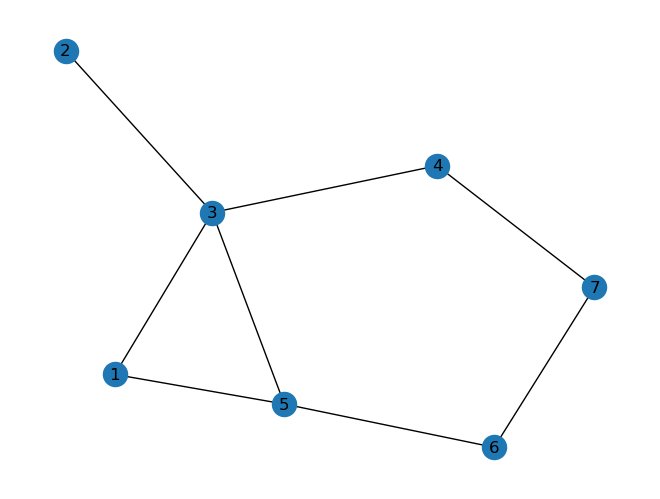

In [5]:
#hãy thực hiện chạy thử đoạn code sau và xem kết quả
#Cho graph vô hướng sau đây với thông tin danh sách cạnh kề
graph = {
  '1' : ['3', '5'],
  '2' : ['3'],
  '3' : ['1', '2', '4', '5'],
  '4' : ['3', '7'],
  '5' : ['1', '3', '6'],
  '6' : ['5', '7'],
  '7' : ['4', '6']
}
G = nx.Graph(graph)
nx.draw(G, with_labels = True)

> Tìm hiểu và áp dụng các thư viện networkX vào để giải lại tất cả các bài tập ở mục 1).

In [93]:
#đã giải ở trên

Cuối cùng, ta xem xét cách tạo graph với node có các đỉnh là các string và vẽ graph

In [2]:
#reset lại graph đã nêu
G = nx.Graph()

In [3]:
G.add_node("Phu")
G.add_nodes_from(["Tai", "Nam", "Hien", "Tuan"])
G.add_nodes_from([("Hien", {"cao": 169}), ("Phuc", {"cao": 160})])

print(G.nodes)
print(G.nodes["Hien"]["cao"])

['Phu', 'Tai', 'Nam', 'Hien', 'Tuan', 'Phuc']
169


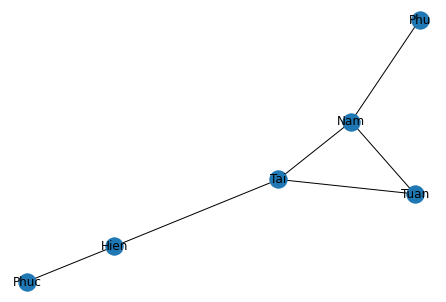

In [4]:
G.add_edge("Hien", "Phuc", weight = 3)
G.add_edge("Tai", "Nam", weight = 3)
G.add_edges_from([("Phu", "Nam"),("Tuan", "Tai")])
G.add_edges_from([("Nam", "Tuan"),("Tai", "Hien")])
nx.draw(G, with_labels = True)
## Nếu code vẽ graph không chạy được thì run: pip install decorator==5.0.9 và restart lại máy

{('Tai', 'Nam'): Text(-0.08237288010672524, -0.19855836645239336, '3'),
 ('Hien', 'Phuc'): Text(0.37124533944731497, 0.785150444151705, '3')}

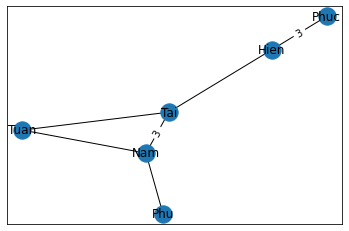

In [5]:
#import matplotlib.pyplot as plt
pos = nx.spring_layout(G) 
nx.draw_networkx(G,pos)
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)

#SV thử tự tìm thêm một số cách vẽ attritube của cạnh / đỉnh